# Backward Repetition Lag-CRP

Measure how often recalls move from a newly revisited repeated item to the neighbours of its earlier presentation. The `min_lag` filter enforces spaced repetitions, and the resulting curve highlights backward spread relative to the full forward/backward profile charted in `repcrp`.


In [1]:
import os

from jaxcmr.analyses.backrepcrp import plot_back_rep_crp
from jaxcmr.helpers import find_project_root, generate_trial_mask, load_data
from jaxcmr.repetition import make_control_dataset
import matplotlib.pyplot as plt

In [2]:
data_name = "LohnasKahana2014"
data_query = "data['list_type'] > 2"
ctrl_query = "data['list_type'] == 1"
min_lag = 4


In [3]:
project_root = find_project_root()
data_path = os.path.join(project_root, 'data', f'{data_name}.h5')
data = load_data(data_path)
trial_mask = generate_trial_mask(data, data_query)
control_dataset = make_control_dataset(data, data_query, ctrl_query, 10)
control_mask = generate_trial_mask(control_dataset, data_query)


/Users/jordangunn/jaxcmr/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:440: DegenerateDataWarning: The BCa confidence interval cannot be calculated. This problem is known to occur when the distribution is degenerate or the statistic is np.min.
  return fun(*args, **kwargs)
/Users/jordangunn/jaxcmr/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:440: DegenerateDataWarning: The BCa confidence interval cannot be calculated. This problem is known to occur when the distribution is degenerate or the statistic is np.min.
  return fun(*args, **kwargs)
/Users/jordangunn/jaxcmr/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:440: DegenerateDataWarning: The BCa confidence interval cannot be calculated. This problem is known to occur when the distribution is degenerate or the statistic is np.min.
  return fun(*args, **kwargs)


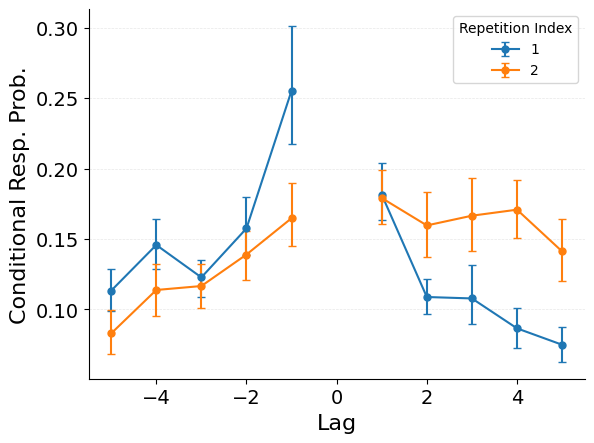

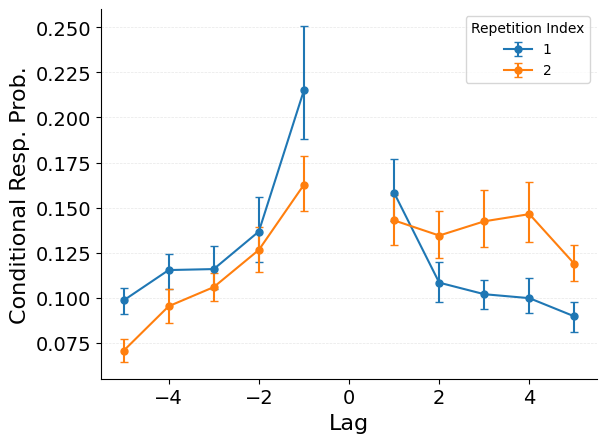

In [4]:
plot_back_rep_crp(
    datasets=data,
    trial_masks=trial_mask,
    min_lag=min_lag,
    labels=("First", "Second"),
    contrast_name="Repetition Index",
)
plot_back_rep_crp(
    datasets=control_dataset,
    trial_masks=control_mask,
    min_lag=min_lag,
    labels=("First", "Second"),
    contrast_name="Repetition Index",
)
plt.show()

## Notes

- Adjust `ctrl_query` to define alternative control populations.
- Modify `min_lag` if you need to tighten or relax the spacing filter.
